In [115]:
import pandas as pd
import seaborn as sns

In [116]:
df = pd.read_csv("https://github.com/dm-fedorov/pandas_basic/blob/master/data/tinkoff.csv?raw=True")
df

,Unnamed: 0,vacancy,company,creation_date,region,income,experience,employment_type,duties,requirements,conditions
0,0,Начинающий специалист по залоговому кредитованию,Тинькофф,2019-01-15,Москва,55000,не требуется,Полная занятость,"- Звонить клиентам, которым банк одобрил креди...",NaN,- График работы 5/2 с плавающими выходными;\n-...
1,1,Начинающий специалист в банк,Тинькофф,2019-01-15,Москва,50000,не требуется,Полная занятость,- Работать с действующими и потенциальными кли...,- Грамотная речь;\n- Уверенный пользователь ПК.,- Стабильную заработную плату: гарантированный...
2,2,Менеджер по работе с корпоративными клиентами ...,Тинькофф,2019-01-15,Москва,50000,1–3 года,Полная занятость,- Самостоятельный поиск и активное привлечение...,"- Желание работать в современном, высококвалиф...",- Обучение у лучших тренеров и наставников бан...
3,3,Менеджер по привлечению юридических лиц,Тинькофф,2019-01-15,Коломна,80000,не требуется,Полная занятость,- Поиск и привлечение юридических лиц;\n- Пров...,"- Активная жизненная позиция;\n- Мобильность, ...","- Работу в успешном, а главное, стабильном Бан..."
4,4,Менеджер по привлечению юридических лиц,Тинькофф,2019-01-15,Одинцово,80000,не требуется,Полная занятость,- Поиск и привлечение юридических лиц;\n- Пров...,"- Активная жизненная позиция;\n- Мобильность, ...","- Работу в успешном, а главное, стабильном Бан..."
...,...,...,...,...,...,...,...,...,...,...,...
2695,2695,Агент по доставке продуктов Тинькофф,Тинькофф,2020-03-02,Иркутск,50000,не требуется,Полная занятость,- Доставлять продукцию компании;\n- Помогать к...,- Умение ориентироваться в городе;\n- Приветст...,- Корпоративная мобильная связь;\n- Работа в ф...
2696,2696,Агент по доставке продуктов Тинькофф,Тинькофф,2020-03-02,Сочи,35000,не требуется,Полная занятость,- Доставлять продукцию компании;\n- Помогать к...,- Умение ориентироваться в городе;\n- Разъездн...,- Корпоративная мобильная связь;\n- Выполнение...
2697,2697,Представитель Тинькофф,Тинькофф,2020-01-30,Пермь,40000,не требуется,Полная занятость,"- Проводить встречи с клиентами, доставлять пр...","- Разъездной формат работы, компания автомобил...","- Работа в формате 5/2, 2/2, дни, свободные от..."
2698,2698,Дизайнер мобильных приложений,Тинькофф,2020-01-22,Москва,0,1–3 года,Полная занятость,- Создание и доработка дизайна финансовых моби...,- Опыт работы в области дизайна и проектирован...,"- Профессиональное развитие: проводим митапы, ..."


In [117]:
df['employment_type'].unique()

<StringArray>
['Полная занятость', 'Частичная занятость', 'Проектная работа', 'Стажировка']
Length: 4, dtype: str

In [118]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2700 entries, 0 to 2699
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Unnamed: 0       2700 non-null   int64
 1   vacancy          2700 non-null   str  
 2   company          2700 non-null   str  
 3   creation_date    2700 non-null   str  
 4   region           2700 non-null   str  
 5   income           2700 non-null   int64
 6   experience       2700 non-null   str  
 7   employment_type  2700 non-null   str  
 8   duties           2700 non-null   str  
 9   requirements     2543 non-null   str  
 10  conditions       2700 non-null   str  
dtypes: int64(2), str(9)
memory usage: 232.2 KB


какие самые частые требования идут от тинькоффа на свои вакансии для полной занятности

In [119]:
from collections import defaultdict

def get_frequentcy_requeremnts(df:pd.DataFrame)-> dict:
    requerements = defaultdict(int)
    for i in df['requirements'].dropna():
        rs = i.split('- ')
        for n in rs:
            if(len(n) == 0):
                continue
            requerements[n.strip()[:-1]] += 1
                # requerements.add()
    return requerements    


# get_frequentcy_requeremnts(df)

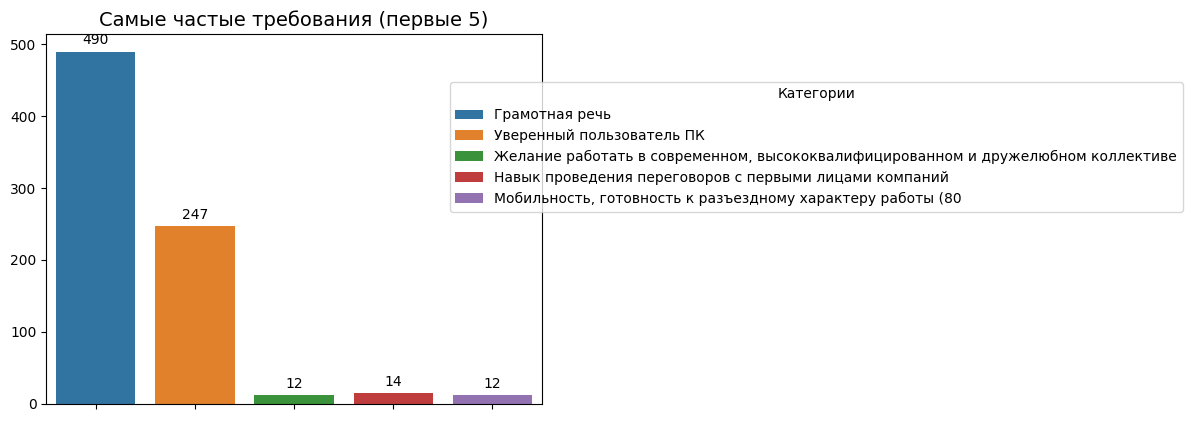

In [120]:
data =get_frequentcy_requeremnts(df)
new_df = pd.DataFrame([data]).T

ax = sns.barplot(new_df.head(5).T, legend=True)
ax.set_xticklabels([])
ax.set_xlabel("")
ax.set_title("Самые частые требования (первые 5)", fontsize=14)

ax.legend(loc = 'lower left', 
          bbox_to_anchor=(0.8, 0.5),
            title="Категории")
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)


In [121]:
df_2 = df[df['experience'] == 'не требуется']
df_2

,Unnamed: 0,vacancy,company,creation_date,region,income,experience,employment_type,duties,requirements,conditions
0,0,Начинающий специалист по залоговому кредитованию,Тинькофф,2019-01-15,Москва,55000,не требуется,Полная занятость,"- Звонить клиентам, которым банк одобрил креди...",NaN,- График работы 5/2 с плавающими выходными;\n-...
1,1,Начинающий специалист в банк,Тинькофф,2019-01-15,Москва,50000,не требуется,Полная занятость,- Работать с действующими и потенциальными кли...,- Грамотная речь;\n- Уверенный пользователь ПК.,- Стабильную заработную плату: гарантированный...
3,3,Менеджер по привлечению юридических лиц,Тинькофф,2019-01-15,Коломна,80000,не требуется,Полная занятость,- Поиск и привлечение юридических лиц;\n- Пров...,"- Активная жизненная позиция;\n- Мобильность, ...","- Работу в успешном, а главное, стабильном Бан..."
4,4,Менеджер по привлечению юридических лиц,Тинькофф,2019-01-15,Одинцово,80000,не требуется,Полная занятость,- Поиск и привлечение юридических лиц;\n- Пров...,"- Активная жизненная позиция;\n- Мобильность, ...","- Работу в успешном, а главное, стабильном Бан..."
5,5,Менеджер по привлечению юридических лиц,Тинькофф,2019-01-15,Орехово-Зуево,80000,не требуется,Полная занятость,- Поиск и привлечение юридических лиц;\n- Пров...,"- Активная жизненная позиция;\n- Мобильность, ...","- Работу в успешном, а главное, стабильном Бан..."
...,...,...,...,...,...,...,...,...,...,...,...
2694,2694,Агент по доставке продуктов Тинькофф,Тинькофф,2020-03-02,Новосибирск,40000,не требуется,Полная занятость,- Доставлять продукцию компании;\n- Помогать к...,- Умение ориентироваться в городе;\n- Разъездн...,- Корпоративная мобильная связь;\n- Работа в ф...
2695,2695,Агент по доставке продуктов Тинькофф,Тинькофф,2020-03-02,Иркутск,50000,не требуется,Полная занятость,- Доставлять продукцию компании;\n- Помогать к...,- Умение ориентироваться в городе;\n- Приветст...,- Корпоративная мобильная связь;\n- Работа в ф...
2696,2696,Агент по доставке продуктов Тинькофф,Тинькофф,2020-03-02,Сочи,35000,не требуется,Полная занятость,- Доставлять продукцию компании;\n- Помогать к...,- Умение ориентироваться в городе;\n- Разъездн...,- Корпоративная мобильная связь;\n- Выполнение...
2697,2697,Представитель Тинькофф,Тинькофф,2020-01-30,Пермь,40000,не требуется,Полная занятость,"- Проводить встречи с клиентами, доставлять пр...","- Разъездной формат работы, компания автомобил...","- Работа в формате 5/2, 2/2, дни, свободные от..."


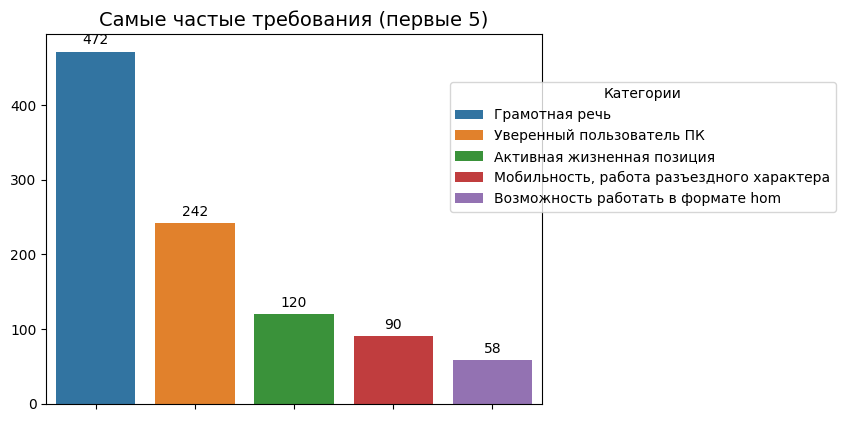

In [122]:

data =get_frequentcy_requeremnts(df_2)
new_df = pd.DataFrame([data]).T

ax = sns.barplot(new_df.head(5).T, legend=True)
ax.set_xticklabels([])
ax.set_xlabel("")
ax.set_title("Самые частые требования (первые 5)", fontsize=14)

ax.legend(loc = 'lower left', 
          bbox_to_anchor=(0.8, 0.5),
            title="Категории")
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

In [123]:
df_3 = df[df['experience'] == '1–3 года']
df_3

,Unnamed: 0,vacancy,company,creation_date,region,income,experience,employment_type,duties,requirements,conditions
2,2,Менеджер по работе с корпоративными клиентами ...,Тинькофф,2019-01-15,Москва,50000,1–3 года,Полная занятость,- Самостоятельный поиск и активное привлечение...,"- Желание работать в современном, высококвалиф...",- Обучение у лучших тренеров и наставников бан...
23,23,QA engineer,Тинькофф,2019-01-15,Москва,0,1–3 года,Полная занятость,- Функциональное и интеграционное тестирование...,- Умение писать и читать SQL запросы (уровень ...,"- Профессиональное развитие: проводим митапы, ..."
24,24,Специалист по тестированию,Тинькофф,2019-01-15,Москва,0,1–3 года,Полная занятость,- Функциональное и интеграционное тестирование...,- Высшее образование;\n- Опыт ручного тестиров...,"- Профессиональное развитие: проводим митапы, ..."
25,25,DevSecOps,Тинькофф,2019-01-15,Москва,0,1–3 года,Полная занятость,- Активное участие в процессе безопасной разра...,- Навыки разработки на одном из интерпретируем...,"- Профессиональное развитие: проводим митапы, ..."
26,26,Менеджер по работе с партнерами,Тинькофф,2019-01-15,Москва,0,1–3 года,Полная занятость,"- Привлечение новых партнеров (переговоры, сог...",- Опыт успешных продаж. Взаимодействие с партн...,- Заработная плата определяется по результатам...
...,...,...,...,...,...,...,...,...,...,...,...
2672,2672,Руководитель направления правового сопровожден...,Тинькофф,2020-10-01,Москва,0,1–3 года,Полная занятость,- Выстраивание работы с нуля\n- Подготовка вну...,- Опыт работы в залоговом кредитовании малого ...,"- Профессиональное развитие: проводим митапы, ..."
2680,2680,Бизнес-тренер soft skills,Тинькофф,2020-01-18,Москва,0,1–3 года,Полная занятость,- Снятие запроса от бизнес заказчика по пробле...,- Умение снимать запросы;\n- Опыт в проведении...,"- Условия: договор ГПД, работа home office, ре..."
2684,2684,Юрист по договорной работе (Страхование),Тинькофф,2020-01-02,Москва,0,1–3 года,Полная занятость,- Юридическое сопровождение бизнес-подразделен...,- Высшее юридическое образование;\n- Стаж не м...,"- Профессиональное развитие: проводим митапы, ..."
2690,2690,Юрист в отдел правового сопровождения договорн...,Тинькофф,2020-01-30,Москва,0,1–3 года,Полная занятость,"- Подготовка, анализ, правовая экспертиза дого...",- Высшее образование;\n- Опыт работы в рамках ...,"- Комфортный офис, расположенный в шаговой дос..."


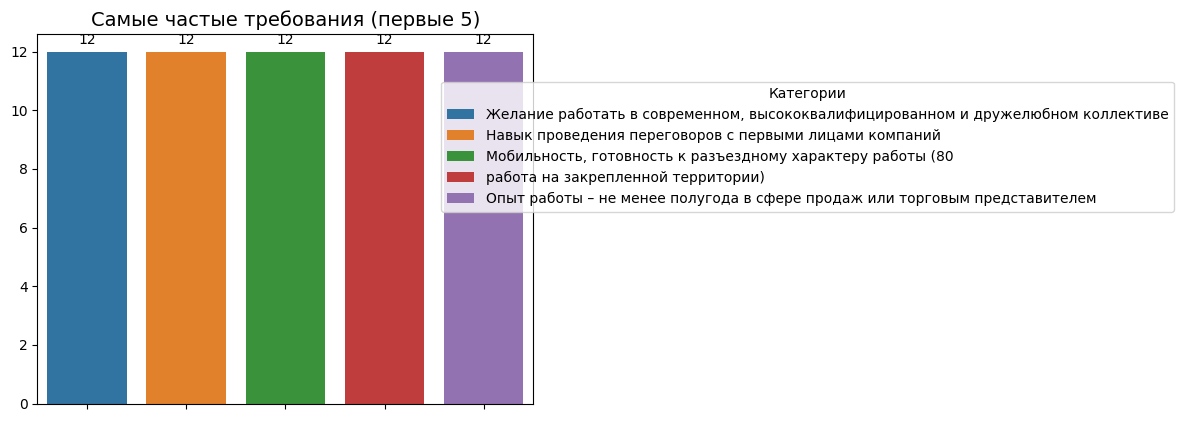

In [124]:

data =get_frequentcy_requeremnts(df_3)
new_df = pd.DataFrame([data]).T

ax = sns.barplot(new_df.head(5).T, legend=True)
ax.set_xticklabels([])
ax.set_xlabel("")
ax.set_title("Самые частые требования (первые 5)", fontsize=14)

ax.legend(loc = 'lower left', 
          bbox_to_anchor=(0.8, 0.5),
            title="Категории")
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

In [125]:
df_4 = df[df['experience'] == '3–6 лет']

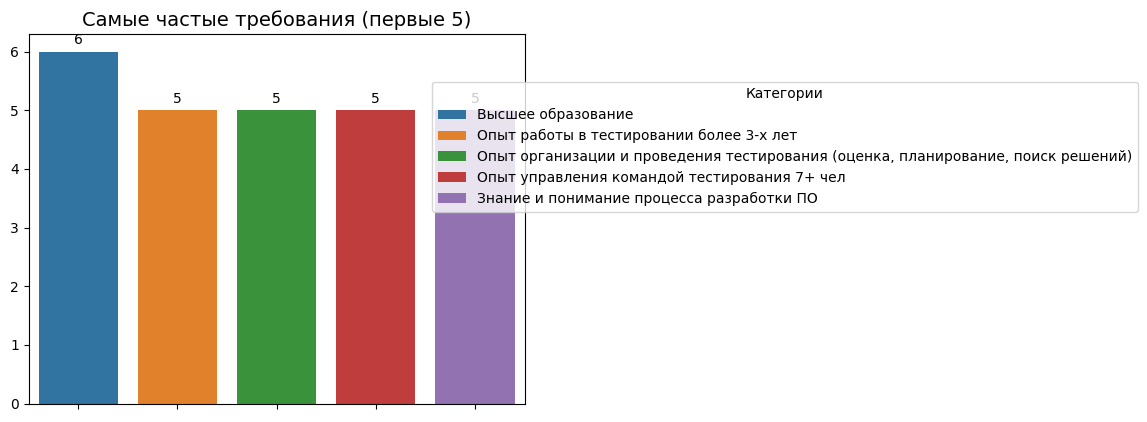

In [126]:

data =get_frequentcy_requeremnts(df_4)
new_df = pd.DataFrame([data]).T

ax = sns.barplot(new_df.head(5).T, legend=True)
ax.set_xticklabels([])
ax.set_xlabel("")
ax.set_title("Самые частые требования (первые 5)", fontsize=14)

ax.legend(loc = 'lower left', 
          bbox_to_anchor=(0.8, 0.5),
            title="Категории")
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)